In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pydataset import data

df = data('USArrests')

print(df)

                Murder  Assault  UrbanPop  Rape
Alabama           13.2      236        58  21.2
Alaska            10.0      263        48  44.5
Arizona            8.1      294        80  31.0
Arkansas           8.8      190        50  19.5
California         9.0      276        91  40.6
Colorado           7.9      204        78  38.7
Connecticut        3.3      110        77  11.1
Delaware           5.9      238        72  15.8
Florida           15.4      335        80  31.9
Georgia           17.4      211        60  25.8
Hawaii             5.3       46        83  20.2
Idaho              2.6      120        54  14.2
Illinois          10.4      249        83  24.0
Indiana            7.2      113        65  21.0
Iowa               2.2       56        57  11.3
Kansas             6.0      115        66  18.0
Kentucky           9.7      109        52  16.3
Louisiana         15.4      249        66  22.2
Maine              2.1       83        51   7.8
Maryland          11.3      300        6

In [10]:
df1=pd.DataFrame(df)
df1.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [11]:
df1 = df1.reset_index()
df1 = df1.rename(columns={'index': 'city'})


,city,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [12]:
df1.head()

,city,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [14]:
df_vertical = pd.melt(frame=df1,id_vars='city',value_vars=['Murder','Assault','UrbanPop','Rape'],var_name = 'Crime')

In [15]:
df_vertical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    200 non-null    object 
 1   Crime   200 non-null    object 
 2   value   200 non-null    float64
dtypes: float64(1), object(2)
memory usage: 4.8+ KB


/tmp/ipykernel_20189/729257106.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_vertical,x = 'Crime',y = 'value',palette ='Set2');


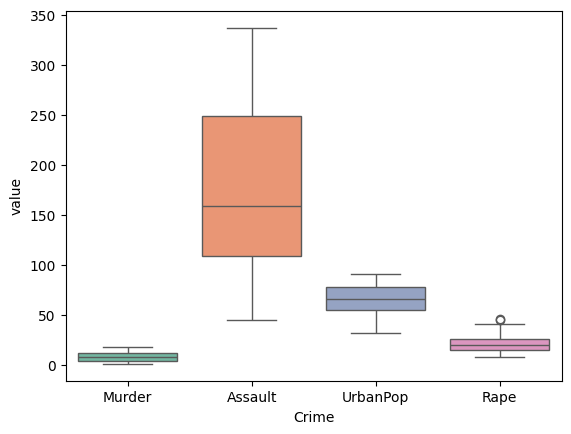

In [18]:
sns.boxplot(df_vertical,x = 'Crime',y = 'value',palette ='Set2');

While in general the deviation of Murder, UrbanPop and Rape is smaller indication a lower variability between different state on this crime, the one in Assault is quite wide indicating state have stituation different.

In [19]:
# Means and variances
print(df.mean())
print(df.var())

Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64
Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64


## Standardize data

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Perform PCA

In [21]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings
loadings = pca.components_.T

# Explained variance
explained_variance = pca.explained_variance_
pve = pca.explained_variance_ratio_

print("Loadings:\n", loadings)
print("PVE:\n", pve)

Loadings:
 [[ 0.53589947 -0.41818087 -0.34123273 -0.6492278 ]
 [ 0.58318363 -0.1879856  -0.26814843  0.74340748]
 [ 0.27819087  0.87280619 -0.37801579 -0.13387773]
 [ 0.54343209  0.16731864  0.81777791 -0.08902432]]
PVE:
 [0.62006039 0.24744129 0.0891408  0.04335752]


## Scree plot (variance explained)

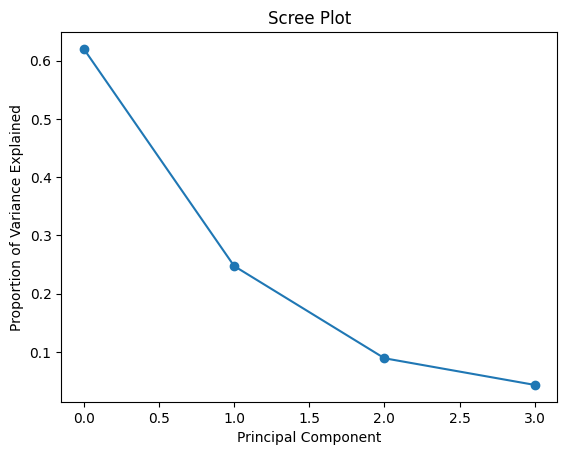

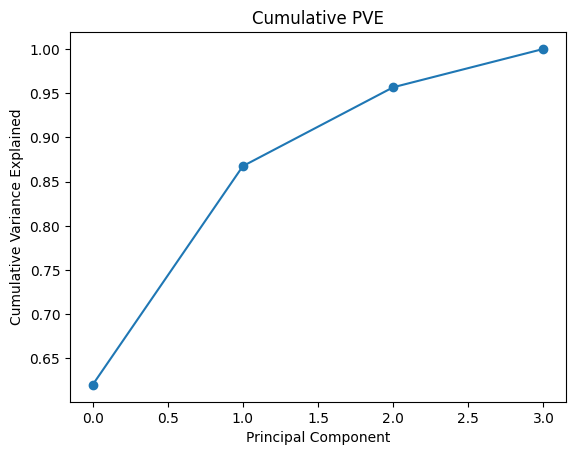

In [22]:
plt.plot(pve, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot")
plt.show()

plt.plot(np.cumsum(pve), marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative PVE")
plt.show()

## SVD

In [23]:
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

# Compare with PCA loadings
print("SVD V^T:\n", VT)
print("PCA components:\n", pca.components_)

SVD V^T:
 [[-0.53589947 -0.58318363 -0.27819087 -0.54343209]
 [-0.41818087 -0.1879856   0.87280619  0.16731864]
 [ 0.34123273  0.26814843  0.37801579 -0.81777791]
 [ 0.6492278  -0.74340748  0.13387773  0.08902432]]
PCA components:
 [[ 0.53589947  0.58318363  0.27819087  0.54343209]
 [-0.41818087 -0.1879856   0.87280619  0.16731864]
 [-0.34123273 -0.26814843 -0.37801579  0.81777791]
 [-0.6492278   0.74340748 -0.13387773 -0.08902432]]


## Introduce missing values

In [24]:
np.random.seed(15)

X = X_scaled.copy()
n_missing = 20

rows = np.random.choice(X.shape[0], n_missing)
cols = np.random.choice(X.shape[1], n_missing)

X_na = X.copy()
X_na[rows, cols] = np.nan

## Low-rank SVD reconstruction function

In [25]:
def fit_svd(X, M=1):
    U, S, VT = np.linalg.svd(X, full_matrices=False)
    return U[:, :M] @ np.diag(S[:M]) @ VT[:M, :]

## Iterative SVD imputation

In [26]:
# Initialize missing values with column means
X_hat = X_na.copy()
col_means = np.nanmean(X_hat, axis=0)

inds = np.where(np.isnan(X_hat))
X_hat[inds] = np.take(col_means, inds[1])

# Iteration
thresh = 1e-7
rel_err = 1
mssold = np.mean((X[~np.isnan(X_na)])**2)
mss0 = mssold

iter_count = 0

while rel_err > thresh:
    iter_count += 1

    # Low-rank approximation
    X_app = fit_svd(X_hat, M=1)

    # Update missing values
    X_hat[np.isnan(X_na)] = X_app[np.isnan(X_na)]

    # Compute error
    mss = np.mean(((X - X_app)[~np.isnan(X_na)])**2)

    rel_err = (mssold - mss) / mss0
    mssold = mss

    print(f"iter: {iter_count}, MSS: {mss:.6f}, Rel.Err: {rel_err:.6f}")

iter: 1, MSS: 0.389545, Rel.Err: 0.605907
iter: 2, MSS: 0.372828, Rel.Err: 0.016912
iter: 3, MSS: 0.371066, Rel.Err: 0.001783
iter: 4, MSS: 0.370845, Rel.Err: 0.000224
iter: 5, MSS: 0.370810, Rel.Err: 0.000035
iter: 6, MSS: 0.370803, Rel.Err: 0.000007
iter: 7, MSS: 0.370802, Rel.Err: 0.000001
iter: 8, MSS: 0.370802, Rel.Err: 0.000000
iter: 9, MSS: 0.370802, Rel.Err: 0.000000


## Evaluate imputation quality

In [27]:
true_values = X[np.isnan(X_na)]
imputed_values = X_app[np.isnan(X_na)]

correlation = np.corrcoef(true_values, imputed_values)[0, 1]
print("Correlation:", correlation)

Correlation: 0.6159729858013876
